<a href="https://colab.research.google.com/github/aedenj/faithful-cuts/blob/main/CSED504_Faithful_Cuts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/aedenj/faithful-cuts.git

Cloning into 'faithful-cuts'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 38 (delta 19), reused 14 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 820.03 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [2]:
!pip install qwen-omni-utils -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 85.9 MB/s eta 0:00:00


In [3]:
!pip install outlines pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 7.3 MB/s eta 0:00:00


In [4]:
!pip install networkx

# Setup

In [5]:
import requests
import gc
import json
import re
from pydantic import BaseModel, Field, ConfigDict

import outlines
from outlines.inputs import Chat, Video

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.video_utils import load_video
import numpy as np

In [6]:
def cleanup_gpu():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

# Extract Scenes

In [7]:
video_url = "https://github.com/intel-iot-devkit/sample-videos/raw/master/bottle-detection.mp4"
video_path = "sample_video.mp4"

try:
    with requests.get(video_url, stream=True, timeout=30) as r:
        r.raise_for_status()
        with open(video_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"Successfully downloaded video to {video_path}")
except Exception as e:
    print(f"Failed to download video: {e}")

Successfully downloaded video to sample_video.mp4


# Generate Scene Descriptions

### Model Setup

In [8]:
from transformers import (
    AutoModelForMultimodalLM,
    AutoProcessor,
)

# SCENE_DESC_MODEL = "Qwen/Qwen3-VL-30B-A3B-Instruct"
# SCENE_DESC_MODEL = "Qwen/Qwen3.5-35B-A3B"
SCENE_DESC_MODEL = "Qwen/Qwen3-VL-8B-Instruct"


qwen_scene_desc_processor = AutoProcessor.from_pretrained(
    SCENE_DESC_MODEL
)


qwen_scene_desc_model = AutoModelForMultimodalLM.from_pretrained(
    SCENE_DESC_MODEL,
    device_map="auto",
    dtype="auto",
)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

In [9]:
frames, metadata = load_video(
    video_path,
    sample_indices_fn=lambda metadata, **kw: np.linspace(
        0, metadata.total_num_frames - 1, 64
    ).round().astype(int),
)

vp = qwen_scene_desc_processor.video_processor
vp.do_sample_frames = False
vp.video_metadata = [metadata]

print(f"frames: {frames.shape}")
print(f"fps: {metadata.fps}, total: {metadata.total_num_frames}, duration: {metadata.duration}")

frames: (64, 360, 640, 3)
fps: 29.833333333333332, total: 1189, duration: 39.85474860335196


In [10]:
class SceneDescription(BaseModel):
    model_config = ConfigDict(extra="forbid")

    summary: str = Field(..., description="A concise but detailed summary of the visual scene depicted in the image or video.")

In [11]:
prompt = [
    {
        "role": "system",
        "content": (
            "You are a precise video understanding system. "
            "Report only information directly supported by the provided video."
        ),
    },
    {
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": Video(frames),
            },
            {
                "type": "text",
                "text": """
Analyze this scene.

Describe what occurs in the scene based only on visually
observable evidence.

Describe people, objects, actions, interactions, locations,
settings, and important changes over time.

Do not infer information that cannot be established from the
video. Do not guess the identities or names of people.
""",
            },
        ],
    }
]

In [12]:
scene_desc_model = outlines.from_transformers(qwen_scene_desc_model, qwen_scene_desc_processor)

In [13]:
formatted_prompt = qwen_scene_desc_processor.tokenizer.apply_chat_template(
    prompt,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,
)

In [14]:
result = scene_desc_model(
    [
        formatted_prompt,
        Video(frames),
    ],
    output_type=SceneDescription,
    max_new_tokens=1200,
    temperature=0.2,
)

In [15]:
scene = SceneDescription.model_validate_json(result)
print(scene)

summary="Three identical plastic water bottles with blue caps, each partially filled with water, are arranged in a row on a white surface against a plain, light-colored wall. A person's hand, wearing a red sleeve, enters the frame and sequentially removes each bottle from the row, one at a time, from left to right. After each removal, the hand places the bottle back in its original position. This process repeats for each bottle, resulting in the bottles being removed and returned to their initial positions multiple times. The video ends with all three bottles back in their original positions."


In [16]:
del scene_desc_model
del qwen_scene_desc_processor
del qwen_scene_desc_model

cleanup_gpu()

# Extract Facts

Here we re-use the DSG (Davidsonian Scene Graph) / TIFA160 annotation taxonomy and decompose a description into atomic "facts" and builds its Spatio-Temporal Semantic Dependency Graph. (Cho et al., ICLR 2024, "Davidsonian Scene Graph: Improving Reliability in
  Fine-grained Evaluation for Text-to-Image Generation")

In [17]:
import utils_video2text as fifa

import re
import collections

_TUPLE_RE = re.compile(
    r"^(?P<broad>[A-Za-z]+)\s*"
    r"(?:-\s*(?P<detailed>[A-Za-z ]*?))?\s*"
    r"\((?P<args>.*)\)\s*$"
)


def _clean_lines(output_str):
    if "</think>" in output_str:
        output_str = output_str.rsplit("</think>", 1)[1]

    if "output:" in output_str:
        output_str = output_str.split("output:", 1)[1]

    return [
        line.strip()
        for line in output_str.strip().splitlines()
        if line.strip()
        and not line.strip().startswith("```")
    ]


def _split_id(line):
    if "|" not in line:
        return None, None

    head, rest = line.split("|", 1)
    head = head.strip().lstrip("#").strip()

    if not head.isdigit():
        return None, None

    return int(head), rest.strip()


def parse_tuples(output_str):
    facts = []
    dropped = []
    seen = set()

    for line in _clean_lines(output_str):
        tuple_id, payload = _split_id(line)

        if tuple_id is None or tuple_id in seen:
            dropped.append(line)
            continue

        seen.add(tuple_id)

        match = _TUPLE_RE.match(payload)

        facts.append(
            {
                "id": tuple_id,
                "raw": line,
                "text": payload,
                "category_broad": (
                    match.group("broad").strip().lower()
                    if match
                    else None
                ),
                "category_detailed": (
                    (match.group("detailed") or "").strip().lower()
                    if match
                    else ""
                ),
                "args": (
                    [
                        arg.strip()
                        for arg in match.group("args").split(",")
                        if arg.strip()
                    ]
                    if match
                    else []
                ),
            }
        )

    facts.sort(key=lambda fact: fact["id"])

    return facts, dropped


def parse_questions(output_str, valid_ids=None):
    """Parse `id | question` lines into {id: question}.

    Parameters
    ----------
    output_str : str
        Raw LLM output containing one question per line.

    valid_ids : set[int] | None
        Optional set of tuple/fact IDs. If provided, questions whose IDs
        are not present in valid_ids are rejected.

    Returns
    -------
    questions : dict[int, str]
        Parsed question text keyed by fact ID.

    dropped : list[str]
        Lines that could not be parsed, had duplicate IDs, referenced
        unknown IDs, or contained an empty question.
    """
    questions = {}
    dropped = []

    for line in _clean_lines(output_str):
        qid, payload = _split_id(line)

        if qid is None:
            dropped.append(line)
            continue

        if qid in questions:
            dropped.append(line)
            continue

        if valid_ids is not None and qid not in valid_ids:
            dropped.append(line)
            continue

        payload = payload.strip()

        if not payload:
            dropped.append(line)
            continue

        questions[qid] = payload

    return questions, dropped


def parse_dependencies(output_str, valid_ids=None):
    deps = {}
    dropped = []
    invalid_parents = []

    for line in _clean_lines(output_str):
        did, payload = _split_id(line)

        if did is None or did in deps:
            dropped.append(line)
            continue

        parents = []

        for tok in payload.split(","):
            tok = tok.strip()

            if not tok.isdigit():
                continue

            pid = int(tok)

            if pid == 0:
                continue

            if pid == did:
                continue

            if pid in parents:
                continue

            if valid_ids is not None and pid not in valid_ids:
                invalid_parents.append(
                    {
                        "child": did,
                        "parent": pid,
                        "raw": line,
                    }
                )
                continue

            parents.append(pid)

        deps[did] = parents

    return deps, dropped, invalid_parents

def validate_dsg(facts, deps):
    ids = {f["id"] for f in facts}

    report = {
        # Hard structural problems
        "missing_entry": sorted(ids - set(deps)),
        "unknown_id": sorted(set(deps) - ids),
        "dangling_parent": sorted(
            {
                p
                for child, parents in deps.items()
                for p in parents
                if p not in ids
            }
        ),

        # Useful structural properties
        "roots": sorted(
            child
            for child, parents in deps.items()
            if not parents
        ),

        "forward_ref": sorted(
            child
            for child, parents in deps.items()
            if any(parent > child for parent in parents)
        ),
    }

    colour = {}
    cycles = []

    def walk(node, path):
        if colour.get(node) == 2:
            return

        if colour.get(node) == 1:
            if node in path:
                cycle_start = path.index(node)
                cycles.append(
                    path[cycle_start:] + [node]
                )
            return

        colour[node] = 1

        for parent in deps.get(node, []):
            walk(
                parent,
                path + [node],
            )

        colour[node] = 2

    for node in deps:
        walk(node, [])

    report["cycles"] = cycles

    num_edges = sum(
        len(parents)
        for parents in deps.values()
    )

    print(
        f"nodes={len(ids)} "
        f"dependency_entries={len(deps)} "
        f"edges={num_edges} "
        f"roots={len(report['roots'])}"
    )

    error_fields = [
        "missing_entry",
        "unknown_id",
        "dangling_parent",
        "cycles",
    ]

    info_fields = [
        "forward_ref",
    ]

    for key in error_fields:
        if report[key]:
            print(f"  ERROR {key}: {report[key]}")

    for key in info_fields:
        if report[key]:
            print(f"  INFO {key}: {report[key]}")

    if not any(report[k] for k in error_fields):
        print(
            "  graph is a well-formed DAG "
            "covering all extracted tuples"
        )

    return report

### Model Setup

In [18]:
LLM_MODEL = "zai-org/GLM-4.7-Flash"

In [19]:
from abc import ABC, abstractmethod

class BaseLLM(ABC):
    def __init__(self, model_name: str):
        self.model_name = model_name

    @abstractmethod
    def completion(self, prompt: str, max_tokens: int = 1024) -> str:
        pass

In [20]:
class GLM47FlashLLM(BaseLLM):

    def __init__(
        self,
        model_name: str = "zai-org/GLM-4.7-Flash",
        torch_dtype="auto",
        device_map="auto",
    ):
        super().__init__(model_name)

        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name
        )

        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            device_map=device_map,
        )

        self.model.eval()

    def delete_model(self):
        del self.model
        del self.tokenizer
        cleanup_gpu()

    @torch.inference_mode()
    def completion(
        self,
        prompt: str,
        config: dict,

    ) -> str:

        messages = [
            {
                "role": "system",
                "content": (
                  "Follow the user's instructions exactly. "
                  "Return only the requested output, with no explanation, "
                  "reasoning, markdown, or commentary."
              ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ]

        inputs = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
            enable_thinking=False,
        ).to(self.model.device)

        outputs = self.model.generate(
            **inputs,
            max_new_tokens=config["max_new_tokens"],

            # These settings were validated against the samples
            # FIFA's video_context_examples file.
            do_sample=config["do_sample"],
            temperature=config["temperature"],
            top_p=config["top_p"],
        )

        generated = outputs[0][inputs["input_ids"].shape[-1]:]

        return self.tokenizer.decode(
            generated,
            skip_special_tokens=True,
        ).strip()

In [21]:
extractor_llm = GLM47FlashLLM(
    "zai-org/GLM-4.7-Flash"
)

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 20.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/3.12k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/872k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 48 files:   0%|          | 0/48 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/751 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

### Extract Facts

In [22]:
FACT_GENERATION_CONFIG = {
    "do_sample": True,
    "temperature": 0.3,
    "top_p": 0.95,
    "max_new_tokens": 2048,
}

tuple_prompt = fifa.make_prompt(
    examples=fifa._TUPLE_EXAMPLES,
    test_input=scene.summary,
    test_query="What happens in the scene?",
    preamble=fifa._TUPLE_PREAMBLE,
    task="tuple"
)

raw_tuple_output = extractor_llm.completion(
    tuple_prompt,
    config=FACT_GENERATION_CONFIG
)

raw_tuples = fifa.parse_with_input_name(raw_tuple_output).strip()
facts, dropped_tuples = parse_tuples(raw_tuples)

print(f"Extracted {len(facts)} facts. Dropped {len(dropped_tuples)} lines.")
for fact in facts:
    print(f"{fact['id']:>2} | {fact['text']}")

Extracted 21 facts. Dropped 0 lines.
 1 | entity - whole (water bottles)
 2 | other - count (water bottles, ==3)
 3 | attribute - color (water bottles, blue)
 4 | entity - part (water bottles' caps)
 5 | attribute - state (water bottles, partially filled with water)
 6 | entity - whole (white surface)
 7 | entity - whole (wall)
 8 | attribute - texture (wall, plain, light-colored)
 9 | entity - whole (person's hand)
10 | entity - part (person's hand's sleeve)
11 | attribute - color (person's hand's sleeve, red)
12 | relation - spatial (water bottles, white surface, on)
13 | relation - spatial (water bottles, wall, against)
14 | relation - spatial (person's hand, water bottles, remove from)
15 | relation - spatial (person's hand, water bottles, place back in)
16 | relation - spatial (person's hand, water bottles, left to right)
17 | action - (person's hand, remove)
18 | action - (person's hand, place back)
19 | event - ambiguity (water bottles, partially filled with water, blue caps, wh

### Generate Questions

In [23]:
QUESTION_GENERATION_CONFIG = {
    "do_sample": True,
    "temperature": 0.4,
    "top_p": 0.95,
    "max_new_tokens": 2048,
}

question_prompt = fifa.make_prompt(
    examples=fifa._QUESTION_EXAMPLES,
    test_input="\n".join([scene.summary, raw_tuples]),
    test_query="What happens in the scene?",
    preamble=fifa._QUESTION_PREAMBLE,
    task="question"
)

raw_question_output = extractor_llm.completion(
    prompt=question_prompt,
    config=QUESTION_GENERATION_CONFIG
)

valid_ids = {f['id'] for f in facts}
questions, dropped_questions = parse_questions(raw_question_output, valid_ids=valid_ids)

print(f"Generated {len(questions)} questions. Dropped {len(dropped_questions)} lines.")
for qid, qtext in sorted(questions.items()):
    print(f"{qid:>2} | {qtext}")

Generated 21 questions. Dropped 0 lines.
 1 | Is there a water bottle?
 2 | Are there three water bottles?
 3 | Are the water bottles blue?
 4 | Are there caps on the water bottles?
 5 | Are the water bottles partially filled with water?
 6 | Is there a white surface?
 7 | Is there a wall?
 8 | Is the wall plain and light-colored?
 9 | Is there a person's hand?
10 | Is there a sleeve on the person's hand?
11 | Is the sleeve red?
12 | Are the water bottles on the white surface?
13 | Are the water bottles against the wall?
14 | Is the person's hand removing the water bottles?
15 | Is the person's hand placing the water bottles back in?
16 | Is the person's hand removing the water bottles from left to right?
17 | Is the person's hand removing the water bottles?
18 | Is the person's hand placing the water bottles back in?
19 | Are there three partially filled with water water bottles with blue caps on a white surface against a plain light-colored wall?
20 | Is there a person's hand with a 

### Dependency Graph Generation

In [24]:
GRAPH_GENERATION_CONFIG = {
    "do_sample": True,
    "temperature": 0.7,
    "top_p": 0.95,
    "max_new_tokens": 2048,
}

dependency_prompt = fifa.make_prompt(
    examples=fifa._DEPENDENCY_EXAMPLES,
    test_input="\n".join([scene.summary, raw_tuples]),
    test_query="What happens in the scene?",
    preamble=fifa._DEPENDENCY_PREAMBLE,
    task="dependency"
)

raw_dependency_output = extractor_llm.completion(
    prompt=dependency_prompt,
    config=GRAPH_GENERATION_CONFIG
)

valid_ids = {f['id'] for f in facts}
dependencies, dropped_dependencies, invalid_parents = parse_dependencies(
    raw_dependency_output,
    valid_ids=valid_ids
)


In [25]:
print(f"Parsed {len(dependencies)} dependency entries.")
print(raw_dependency_output)
if invalid_parents:
    print(f"Warning: Found {len(invalid_parents)} invalid parent references.")

report = validate_dsg(facts, dependencies)

print(f"\n\nGeneral Validity: {report}")

Parsed 21 dependency entries.
1 | 0
2 | 0
3 | 0
4 | 0
5 | 0
6 | 0
7 | 0
8 | 0
9 | 0
10 | 0
11 | 0
12 | 0
13 | 0
14 | 0
15 | 0
16 | 0
17 | 0
18 | 0
19 | 0
20 | 0
21 | 0
nodes=21 dependency_entries=21 edges=0 roots=21
  graph is a well-formed DAG covering all extracted tuples


General Validity: {'missing_entry': [], 'unknown_id': [], 'dangling_parent': [], 'roots': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], 'forward_ref': [], 'cycles': []}


In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import textwrap
from matplotlib.lines import Line2D


def build_fifa_graph(
    facts,
    questions,
    dependencies,
):
    G = nx.DiGraph()

    facts_by_id = {
        fact["id"]: fact
        for fact in facts
    }

    all_ids = sorted(
        set(facts_by_id)
        | set(questions)
        | set(dependencies)
    )

    for fact_id in all_ids:
        fact = facts_by_id.get(fact_id, {})

        G.add_node(
            fact_id,
            fact=fact.get("text", ""),
            broad_type=(
                fact.get("category_broad")
                or "unknown"
            ),
            detailed_type=fact.get(
                "category_detailed",
                "",
            ),
            args=fact.get(
                "args",
                [],
            ),
            question=questions.get(
                fact_id,
                "",
            ),
        )

    # FIFA dependency format: child_id -> [parent ids]
    #
    # We reverse that when constructing the graph so the
    # visual arrow reads: prerequisite fact ---> dependent fact
    for child_id, parent_ids in dependencies.items():

        for parent_id in parent_ids:

            # FIFA's 0 means "no dependency".
            if parent_id == 0:
                continue

            # Handle malformed model output where the
            # dependency references an unknown ID.
            if parent_id not in G:
                G.add_node(
                    parent_id,
                    fact="",
                    broad_type="unknown",
                    detailed_type="",
                    args=[],
                    question="",
                )

            G.add_edge(
                parent_id,
                child_id,
            )

    return G



def draw_fifa_graph(G):
    plt.figure(figsize=(24, 16))

    pos = nx.spring_layout(
        G,
        seed=42,
        k=2.2,
        iterations=150,
    )

    categories = [
        "entity",
        "attribute",
        "action",
        "relation",
        "event",
        "other",
        "unknown",
    ]

    node_shapes = {
        "entity": "o",
        "attribute": "s",
        "action": "^",
        "relation": "D",
        "event": "h",
        "other": "v",
        "unknown": "o",
    }

    # Draw nodes grouped by FIFA broad fact type.
    for category in categories:
        nodes = [
            node_id
            for node_id, data in G.nodes(data=True)
            if data.get("broad_type", "unknown") == category
        ]

        if not nodes:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes,
            node_shape=node_shapes[category],
            node_size=7000,
        )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=20,
        width=1.5,
        connectionstyle="arc3,rad=0.05",
    )

    labels = {}

    for node_id, data in G.nodes(data=True):
        fact = textwrap.fill(
            data.get("fact", "") or "",
            width=35,
        )

        question = textwrap.fill(
            data.get("question", "") or "",
            width=40,
        )

        labels[node_id] = (
            f"#{node_id}\n"
            f"{fact}\n\n"
            f"Q: {question}"
        )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=7,
    )

    legend_handles = [
        Line2D(
            [0], [0],
            marker=node_shapes[category],
            linestyle="None",
            markersize=10,
            label=category,
        )
        for category in categories
        if any(
            data.get("broad_type", "unknown") == category
            for _, data in G.nodes(data=True)
        )
]
    plt.legend(
        handles=legend_handles,
        title="Fact Type",
        loc="upper left",
    )

    plt.title(
        "FIFA Fact / Question Dependency Graph",
        fontsize=16,
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [27]:
G = build_fifa_graph(
    facts,
    questions,
    dependencies,
)

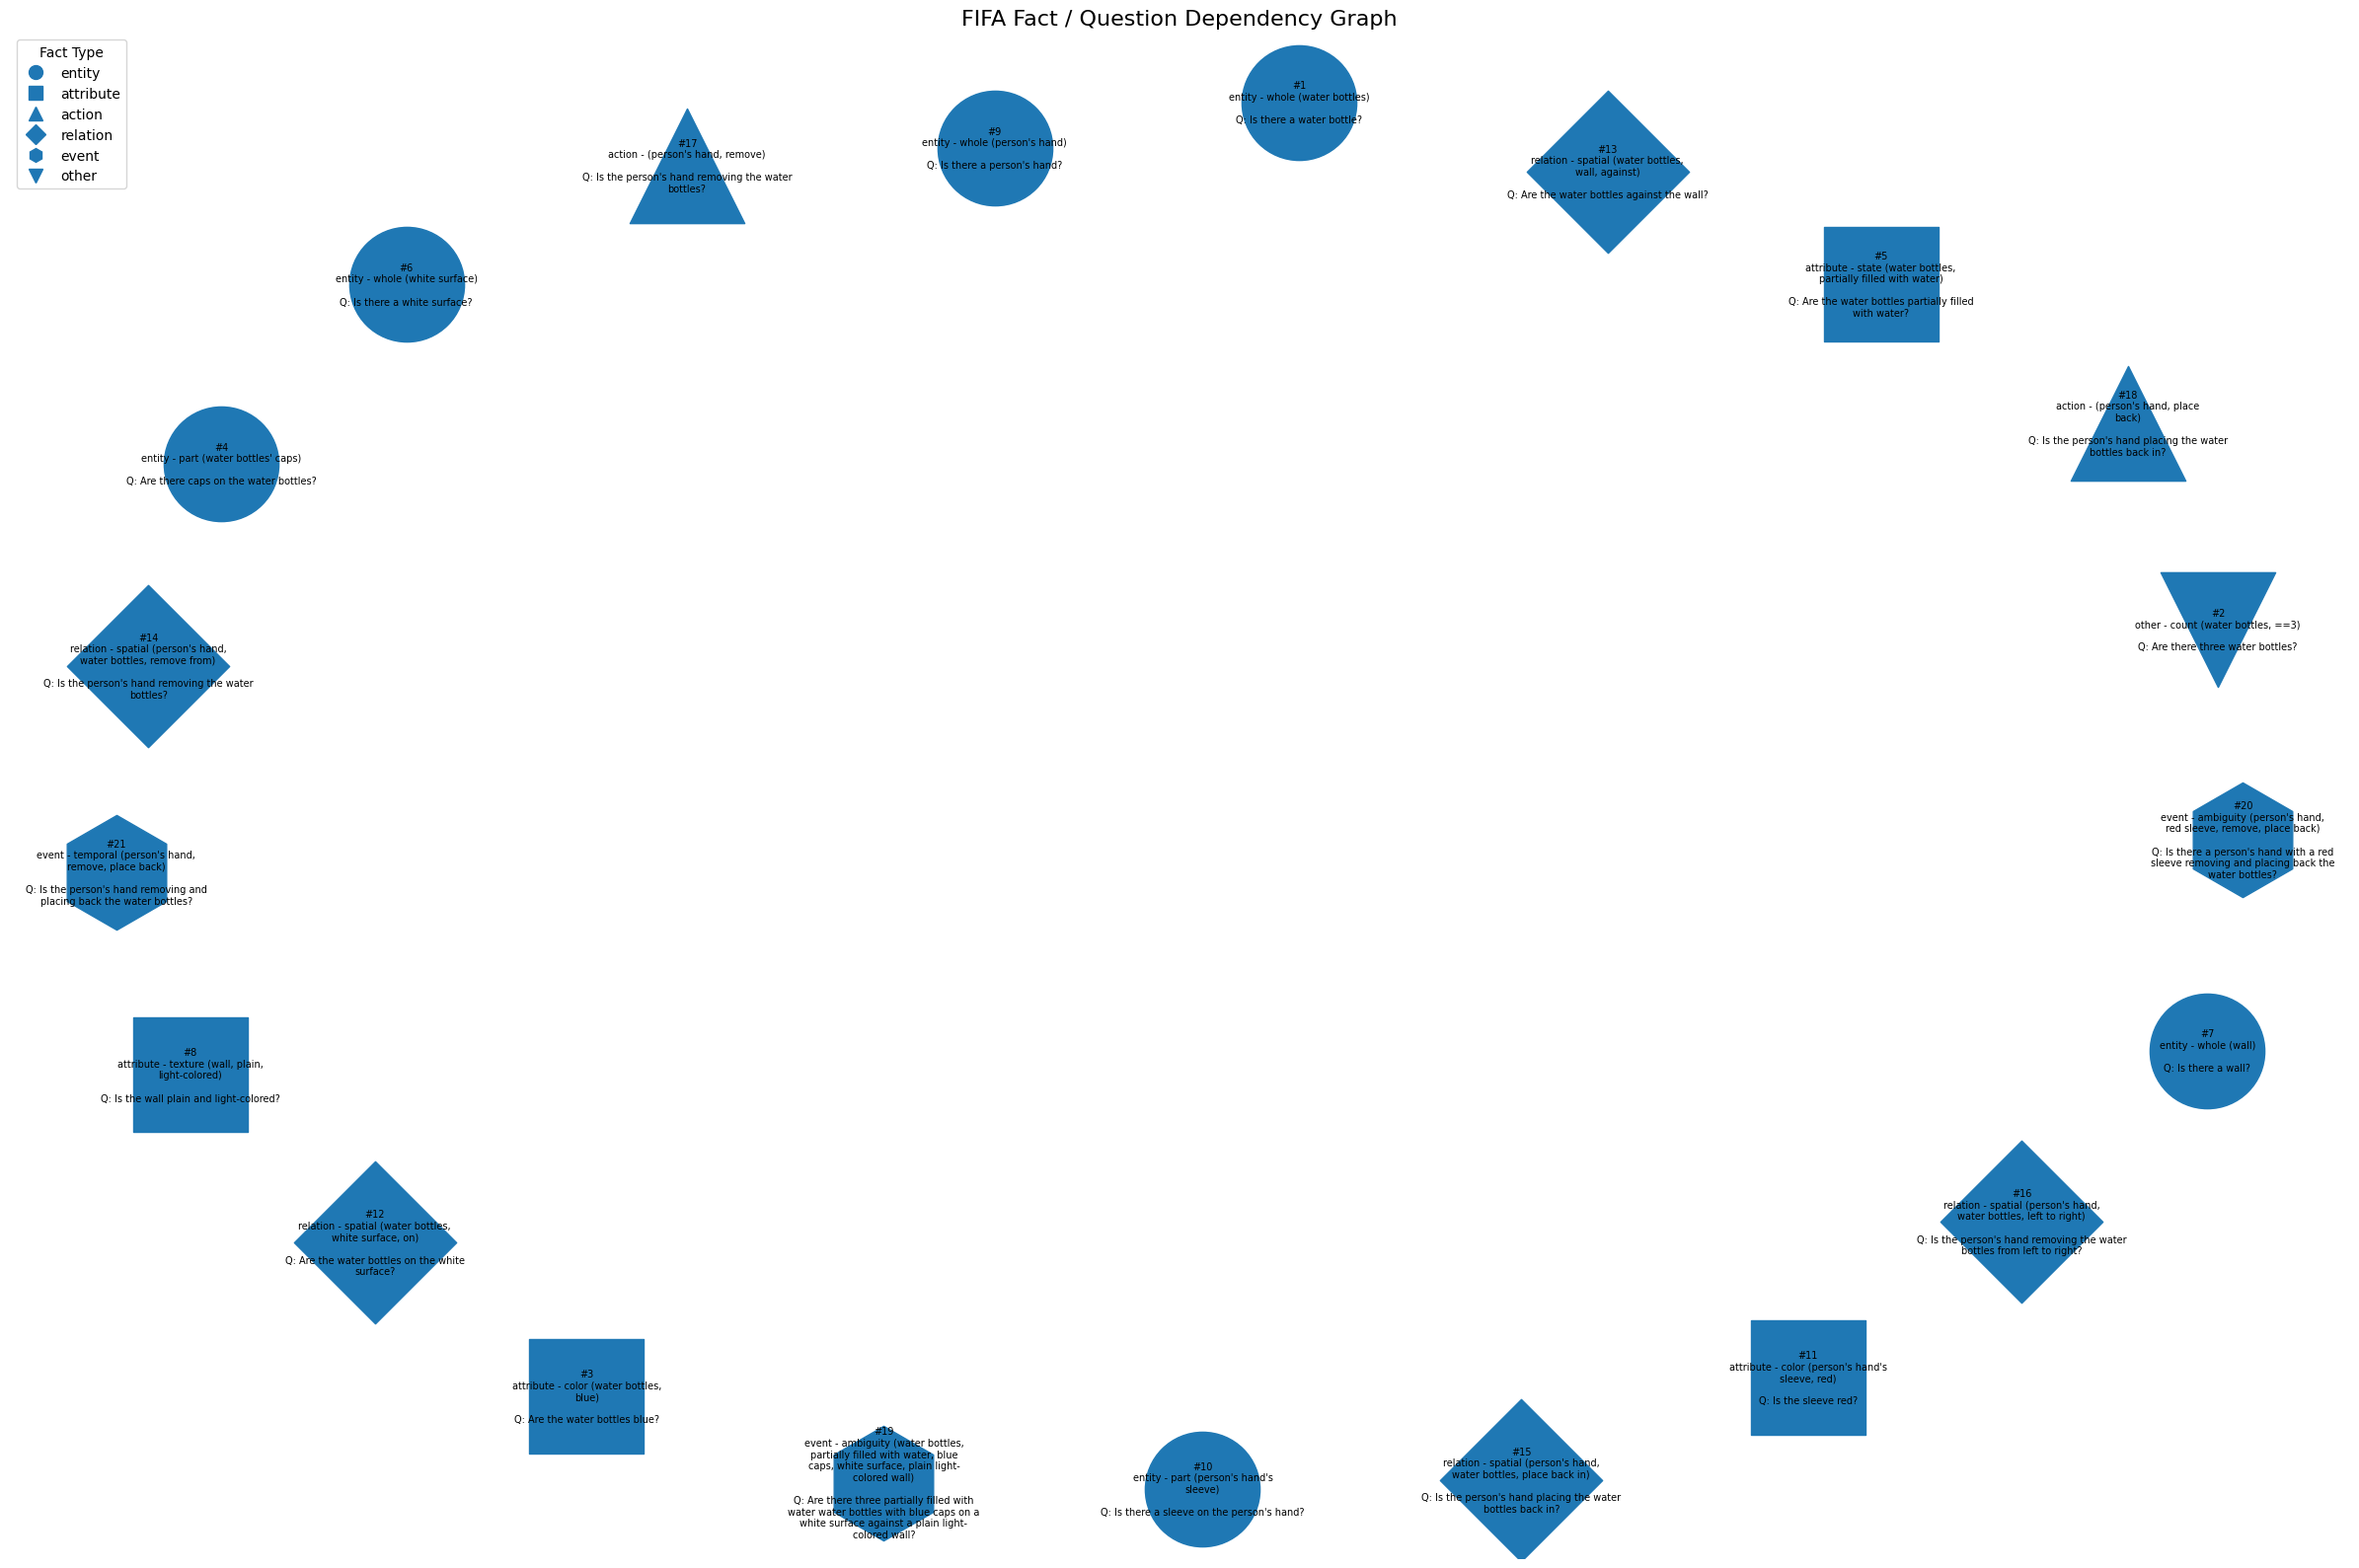

In [28]:
draw_fifa_graph(G)

## Dependency Graph (STSDG)

In [29]:
stsdg = [
    {
        **f,
        "question": questions.get(f["id"]),
        "parents": [p for p in dependencies.get(f["id"], []) if p != 0],
    }
    for f in facts
]

deps_clean = {
    k: [p for p in v if p != 0]
    for k, v in dependencies.items()
}

id2text = {f["id"]: f["text"] for f in facts}
for rec in stsdg:
    parents = ", ".join(id2text.get(p, f"?{p}") for p in rec["parents"]) or "-"
    print(f"{rec['id']:>3}  {rec['text']}")
    print(f"     Q: {rec['question']}")
    print(f"     parents: {parents}")

complete = [
    r for r in stsdg
    if r["question"] is not None and r["id"] in dependencies
]
print(f"\n{len(complete)}/{len(stsdg)} facts have a tuple, question and dependency entry")


  1  entity - whole (water bottles)
     Q: Is there a water bottle?
     parents: -
  2  other - count (water bottles, ==3)
     Q: Are there three water bottles?
     parents: -
  3  attribute - color (water bottles, blue)
     Q: Are the water bottles blue?
     parents: -
  4  entity - part (water bottles' caps)
     Q: Are there caps on the water bottles?
     parents: -
  5  attribute - state (water bottles, partially filled with water)
     Q: Are the water bottles partially filled with water?
     parents: -
  6  entity - whole (white surface)
     Q: Is there a white surface?
     parents: -
  7  entity - whole (wall)
     Q: Is there a wall?
     parents: -
  8  attribute - texture (wall, plain, light-colored)
     Q: Is the wall plain and light-colored?
     parents: -
  9  entity - whole (person's hand)
     Q: Is there a person's hand?
     parents: -
 10  entity - part (person's hand's sleeve)
     Q: Is there a sleeve on the person's hand?
     parents: -
 11  attribute 

In [31]:
def gold_dependencies(item_id):
    sub = fifa._TIFA160_DF[fifa._TIFA160_DF.item_id == item_id]
    gold = {}
    for n, raw in enumerate(sub.dependency.tolist()):
        parents = [
            int(t.strip()) for t in str(raw).split(",")
            if t.strip().isdigit() and int(t.strip()) != 0
        ]
        gold[n + 1] = parents
    return gold


def gold_for(item_id):
    sub = fifa._TIFA160_DF[fifa._TIFA160_DF.item_id == item_id]
    text = sub.text.tolist()[0]
    query = sub.input_query.tolist()[0]
    gold_tuples = sub.tuple.tolist()
    return text, query, gold_tuples, None


def build_examples(task, exclude_ids=frozenset()):
    ids = [i for i in fifa.TIFA160_ICL_TRAIN_IDS if i not in exclude_ids]
    return fifa.get_tifa_examples(fifa._TIFA160_DF, ids, task=task)


# Feed the GOLD tuples rather than the predicted ones, so this measures dependency
# generation in isolation instead of compounding tuple-extraction error.
for item_id in ("video_001", "video_002", "video_003"):
    text, query, gold_tuples, _ = gold_for(item_id)
    gold_block = "\n".join(f"{i + 1} | {t}" for i, t in enumerate(gold_tuples))
    p = fifa.make_prompt(
        examples=build_examples("dependency", exclude_ids={item_id}),
        test_input="\n".join([text, gold_block]),
        test_query=query,
        preamble=fifa._DEPENDENCY_PREAMBLE,
        task="dependency",
    )
    pred, dropped, _ = parse_dependencies(
        fifa.parse_with_input_name(
            extractor_llm.completion(p, config=GRAPH_GENERATION_CONFIG)
        ).strip(),
        valid_ids=set(range(1, len(gold_tuples) + 1)),
    )
    gold = gold_dependencies(item_id)

    exact = sum(1 for k in gold if set(pred.get(k, [])) == set(gold[k]))
    inter = sum(len(set(pred.get(k, [])) & set(gold[k])) for k in gold)
    union = sum(len(set(pred.get(k, [])) | set(gold[k])) for k in gold)
    print(f"\n{item_id}: {exact}/{len(gold)} exact parent-set match, "
          f"edge Jaccard {inter / union if union else 1.0:.2f}, dropped={len(dropped)}")
    for k in sorted(gold):
        mark = " " if set(pred.get(k, [])) == set(gold[k]) else "x"
        print(f"  {mark} {k:>3}  gold={gold[k] or '-'}  pred={pred.get(k, []) or '-'}")


video_001: 7/10 exact parent-set match, edge Jaccard 0.47, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
      3  gold=-  pred=-
      4  gold=-  pred=-
      5  gold=[1, 2]  pred=[1, 2]
      6  gold=[1, 3]  pred=[1, 3]
      7  gold=[1, 4]  pred=[1, 4]
  x   8  gold=[5, 7]  pred=[5, 6]
  x   9  gold=[6, 7]  pred=[5, 7]
  x  10  gold=[8, 9]  pred=[5, 6, 7]

video_002: 2/10 exact parent-set match, edge Jaccard 0.32, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
  x   3  gold=[1, 2]  pred=[1]
  x   4  gold=[1]  pred=[1, 2]
  x   5  gold=[1]  pred=[1, 2]
  x   6  gold=[1, 4]  pred=[3]
  x   7  gold=[1, 5]  pred=[3]
  x   8  gold=[3, 6]  pred=[4, 6]
  x   9  gold=[3, 7]  pred=[4, 7]
  x  10  gold=[6, 7]  pred=[4, 6, 7, 8]

video_003: 5/9 exact parent-set match, edge Jaccard 0.56, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
      3  gold=-  pred=-
      4  gold=[1, 2]  pred=[1, 2]
      5  gold=[3]  pred=[3]
  x   6  gold=[1, 5]  pred=[1, 3]
  x   7  

## Controlled Hallucination Injection

In [32]:
DESCRIPTION = scene.summary
QUERY = "What happens in the scene?"

INJECTION_CONFIG = {
    "do_sample": True,
    "temperature": 0.2,
    "top_p": 0.9,
    "max_new_tokens": 512,
}


In [33]:
import json

HALLUCINATION_TYPES = {
    "entity": "Replace one entity (a person, animal, or object) with a different one.",
    "attribute": "Change one attribute (colour, size, material, or state) of an entity.",
    "location": "Change the location or setting in which the scene takes place.",
    "action": "Change one action or verb to a different, incompatible action.",
    "relation": "Change a spatial relationship between two entities, or remove one participant.",
    "temporal": "Reverse the order of two events that occur in sequence.",
}

INJECT_PROMPT = """You are constructing a controlled evaluation set for a video \
description faithfulness metric.

Given a description, introduce EXACTLY ONE factual error of the requested type. The \
edit must be minimal: change as few words as possible and leave the rest of the \
description untouched.

Error type: {type_name}
Instruction: {type_instruction}

Description:
{description}

Respond with only a JSON object and no other text:
{{"hallucination_type": "{type_name}",
  "original_span": "<the exact substring of the description you are replacing, copied verbatim>",
  "replacement_span": "<the text that replaces it>",
  "rationale": "<one sentence stating what is now false>"}}

The value of "original_span" must appear verbatim in the description exactly once."""


def inject(description: str, htype: str, attempts: int = 4):
    """Return one minimally-perturbed variant, or None if every attempt failed.

    The model only proposes a span pair; the edit is applied here with str.replace so
    exactly one localised change is made. A model that rewrites the whole description
    would make any score drop unattributable to the injected error.
    """
    for _ in range(attempts):
        raw = extractor_llm.completion(
            INJECT_PROMPT.format(
                type_name=htype,
                type_instruction=HALLUCINATION_TYPES[htype],
                description=description,
            ),
            config=INJECTION_CONFIG,
        )
        try:
            payload = json.loads(raw[raw.index("{"):raw.rindex("}") + 1])
            original = payload["original_span"]
            replacement = payload["replacement_span"]
        except (ValueError, KeyError):
            continue
        if not original.strip() or original == replacement:
            continue
        if description.count(original) != 1:
            continue
        return {
            "variant": htype,
            "original_span": original,
            "replacement_span": replacement,
            "rationale": payload.get("rationale", ""),
            "description": description.replace(original, replacement, 1),
        }
    return None


In [37]:
def run_fifa_stages(description: str, query: str = None):
    """Tuple -> question -> dependency for one description, using the same prompts
    and parsers as the walkthrough cells above."""
    query = QUERY if query is None else query

    tuple_p = fifa.make_prompt(
        examples=fifa._TUPLE_EXAMPLES, test_input=description, test_query=query,
        preamble=fifa._TUPLE_PREAMBLE, task="tuple",
    )
    raw_t = fifa.parse_with_input_name(
        extractor_llm.completion(tuple_p, config=FACT_GENERATION_CONFIG)
    ).strip()
    facts, dropped_t = parse_tuples(raw_t)
    ids = {f["id"] for f in facts}

    question_p = fifa.make_prompt(
        examples=fifa._QUESTION_EXAMPLES,
        test_input="\n".join([description, raw_t]), test_query=query,
        preamble=fifa._QUESTION_PREAMBLE, task="question",
    )
    raw_q = fifa.parse_with_input_name(
        extractor_llm.completion(question_p, config=QUESTION_GENERATION_CONFIG)
    ).strip()
    questions, dropped_q = parse_questions(raw_q)

    dependency_p = fifa.make_prompt(
        examples=fifa._DEPENDENCY_EXAMPLES,
        test_input="\n".join([description, raw_t]), test_query=query,
        preamble=fifa._DEPENDENCY_PREAMBLE, task="dependency",
    )
    raw_d = fifa.parse_with_input_name(
        extractor_llm.completion(dependency_p, config=GRAPH_GENERATION_CONFIG)
    ).strip()
    deps, dropped_d, _ = parse_dependencies(raw_d, valid_ids=ids)

    return {
        "description": description,
        "facts": facts,
        "questions": questions,
        "deps": deps,
        "raw": {"tuples": raw_t, "questions": raw_q, "dependencies": raw_d},
        "n_dropped": len(dropped_t) + len(dropped_q) + len(dropped_d),
    }


In [35]:
variants = {}
for _htype in HALLUCINATION_TYPES:
    _v = inject(DESCRIPTION, _htype)
    if _v is None:
        print(f"{_htype:10s} FAILED after retries")
        continue
    variants[_htype] = _v
    print(f"{_htype:10s} {_v['original_span']!r}  ->  {_v['replacement_span']!r}")
    print(f"           {_v['rationale']}")

print(f"\n{len(variants)}/{len(HALLUCINATION_TYPES)} variants generated")


entity     "A person's hand"  ->  "A cat's paw"
           The hand is replaced by a cat's paw, which is a different entity.
attribute  'Three identical plastic water bottles with blue caps'  ->  'Three identical plastic water bottles with red caps'
           The color of the caps has been changed from blue to red.
location   'on a white surface against a plain, light-colored wall'  ->  'on a white surface against a plain, light-colored floor'
           The setting is now described as a floor instead of a wall.
action     'removes each bottle from the row'  ->  'breaks each bottle from the row'
           The action of breaking the bottles is incompatible with the description of them being returned to their original positions.
relation   'sequentially removes each bottle from the row, one at a time, from left to right'  ->  'sequentially removes each bottle from the row, one at a time, from right to left'
           The spatial direction of the removal process is reversed.
temporal  

In [38]:
records = {"original": {"variant": "original", "description": DESCRIPTION}}
records.update(variants)

pipelines = {}
for _name, _rec in records.items():
    _out = run_fifa_stages(_rec["description"])
    _out.update({k: _rec.get(k) for k in ("variant", "original_span", "replacement_span")})

    # Did the injected error survive into the extracted facts? If not, FIFA cannot
    # possibly detect it, and that is a finding about the extractor rather than the
    # verifier.
    if _rec.get("replacement_span"):
        _words = [w for w in re.findall(r"[a-z]+", _rec["replacement_span"].lower())
                  if len(w) > 3]
        _out["perturbation_in_facts"] = [
            f["id"] for f in _out["facts"]
            if any(w in f["text"].lower() for w in _words)
        ]
    else:
        _out["perturbation_in_facts"] = None

    pipelines[_name] = _out
    print(f"{_name:10s} facts={len(_out['facts']):>3} "
          f"questions={len(_out['questions']):>3} dropped={_out['n_dropped']:>2} "
          f"perturbation in facts: {_out['perturbation_in_facts']}")


original   facts= 27 questions= 27 dropped= 0 perturbation in facts: None
entity     facts= 28 questions= 28 dropped= 0 perturbation in facts: []
attribute  facts= 22 questions= 22 dropped= 0 perturbation in facts: [1, 2, 3, 4, 5, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
location   facts= 18 questions= 18 dropped= 0 perturbation in facts: [6, 7, 11, 12]
action     facts= 23 questions= 23 dropped= 0 perturbation in facts: [1, 2, 3, 4, 5, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23]
relation   facts= 33 questions= 33 dropped= 0 perturbation in facts: [1, 2, 3, 4, 5, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 31, 32, 33]
temporal   facts= 20 questions= 20 dropped= 0 perturbation in facts: [1, 2, 5, 11, 12, 13, 14, 15, 16, 18, 19]


# Verify Facts

In [ ]:
try:
    extractor_llm.delete_model()
    del extractor_llm
except NameError:
    pass

for _name in ("glm_struct", "glm_model", "glm_tokenizer"):
    globals().pop(_name, None)

cleanup_gpu()

if torch.cuda.is_available():
    print(f"allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB, "
          f"reserved: {torch.cuda.memory_reserved() / 1e9:.1f} GB")


In [ ]:
from transformers import Qwen3VLMoeForConditionalGeneration, AutoProcessor

VQA_MODEL = "Qwen/Qwen3-VL-30B-A3B-Instruct"

vqa_processor = AutoProcessor.from_pretrained(VQA_MODEL)
vqa_model = Qwen3VLMoeForConditionalGeneration.from_pretrained(
    VQA_MODEL, dtype="auto", device_map="auto"
)

# Same frame-sampling contract as the description stage: we hand over pre-sampled
# frames, so the processor must not resample, and it needs the real metadata or the
# per-frame timestamps written into the prompt will be wrong.
vqa_vp = vqa_processor.video_processor
vqa_vp.do_sample_frames = False
vqa_vp.video_metadata = [metadata]


def answer(question: str, video_frames=None, max_new_tokens: int = 128) -> str:
    video_frames = frames if video_frames is None else video_frames
    messages = [{
        "role": "user",
        "content": [
            {"type": "video", "video": video_frames},
            {"type": "text", "text": question},
        ],
    }]
    text = vqa_processor.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = vqa_processor(
        text=text, videos=[video_frames], padding=True, return_tensors="pt"
    ).to(vqa_model.device)
    out = vqa_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return vqa_processor.tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()


print(answer("Is there a bottle?"))


In [ ]:
_AFFIRM = {"yes", "yeah", "yep", "correct", "true", "affirmative"}
_DENY = {"no", "nope", "not", "false", "incorrect", "none", "never"}


def fifa_score(ans: str) -> float:
    """Verbatim reproduction of eval_video2text.py:63."""
    return float("yes" in ans.lower())


def strict_score(ans: str):
    """Return 1.0 / 0.0, or None when the answer is genuinely ambiguous.

    eval_video2text.py:63 does a bare substring test, so "yesterday" scores 1.0 and
    "There is no dog, yes I am sure" scores 1.0. Leading token wins here instead.
    """
    text = re.sub(r"[^a-z' ]+", " ", ans.lower()).strip()
    tokens = text.split()
    if not tokens:
        return None
    if tokens[0] in _AFFIRM:
        return 1.0
    if tokens[0] in _DENY:
        return 0.0
    if re.search(r"\bthere (is|are) no\b|\b(does|do|did) not\b|\bis not\b", text):
        return 0.0
    if re.search(r"\byes\b", text):
        return 1.0
    if re.search(r"\bno\b", text):
        return 0.0
    return None


def propagate_reference(scores, deps):
    """Single pass in dict order, reproducing eval_video2text.py:68-84.

    Order-dependent by construction: a parent zeroed after its child was visited
    does not zero that child. Kept so the reference number is reportable.
    """
    scores, validity = dict(scores), {}
    for did, parents in deps.items():
        if did not in scores:
            continue
        if any(scores.get(p) == 0 for p in parents):
            scores[did], validity[did] = 0.0, False
        else:
            validity[did] = True
    return scores, validity


def propagate_transitive(scores, deps):
    """Iterate to a fixpoint so zeroing propagates down the whole chain."""
    scores, validity = dict(scores), {d: True for d in deps if d in scores}
    changed = True
    while changed:
        changed = False
        for did, parents in deps.items():
            if did not in scores or scores[did] == 0:
                continue
            if any(scores.get(p) == 0 for p in parents):
                scores[did], validity[did] = 0.0, False
                changed = True
    return scores, validity


In [ ]:
scored = [r for r in stsdg if r["question"]]
assert scored, "no questions to score; re-run the question generation cell"

answers = {r["id"]: answer(r["question"]) for r in scored}

raw_fifa = {i: fifa_score(a) for i, a in answers.items()}
raw_strict = {i: strict_score(a) for i, a in answers.items()}

ambiguous = [i for i, s in raw_strict.items() if s is None]
raw_strict_filled = {i: (0.0 if s is None else s) for i, s in raw_strict.items()}

ref_scores, ref_validity = propagate_reference(raw_fifa, deps_clean)
tr_scores, tr_validity = propagate_transitive(raw_strict_filled, deps_clean)


def mean(d):
    return sum(d.values()) / len(d) if d else float("nan")


print(f"{'id':>3}  {'score':>5}  {'valid':>5}  question / answer")
for r in scored:
    i = r["id"]
    print(f"{i:>3}  {tr_scores[i]:>5.0f}  {str(tr_validity.get(i, True)):>5}  {r['question']}")
    print(f"       -> {answers[i][:90]}")

print()
print(f"ambiguous answers        : {len(ambiguous)} {ambiguous}")
print(f"fifa vs strict disagree  : "
      f"{sorted(i for i in raw_fifa if raw_fifa[i] != raw_strict_filled[i])}")
print()
print(f"no-dependency  (reference metric) : {mean(raw_fifa):.3f}")
print(f"single-pass    (reference metric) : {mean(ref_scores):.3f}")
print(f"transitive     (corrected)        : {mean(tr_scores):.3f}")
print(f"single-pass vs transitive differ  : "
      f"{sorted(i for i in ref_scores if ref_scores[i] != tr_scores[i])}")

faithfulness = {
    "n_facts": len(scored),
    "n_ambiguous": len(ambiguous),
    "average_score_without_dep": mean(raw_fifa),
    "average_score_reference": mean(ref_scores),
    "average_score_transitive": mean(tr_scores),
    "answers": answers,
    "scores": tr_scores,
    "validity": tr_validity,
}


In [ ]:
def score_record(rec, video_frames=None):
    scored = [f for f in rec["facts"] if f["id"] in rec["questions"]]
    if not scored:
        return None
    answers = {f["id"]: answer(rec["questions"][f["id"]], video_frames) for f in scored}

    strict_raw = {i: strict_score(a) for i, a in answers.items()}
    filled = {i: (0.0 if s is None else s) for i, s in strict_raw.items()}
    transitive, validity = propagate_transitive(filled, rec["deps"])
    reference, _ = propagate_reference(
        {i: fifa_score(a) for i, a in answers.items()}, rec["deps"]
    )
    return {
        "n_facts": len(scored),
        "n_ambiguous": sum(1 for s in strict_raw.values() if s is None),
        "average_score_without_dep": sum(filled.values()) / len(filled),
        "average_score_reference": sum(reference.values()) / len(reference),
        "average_score_transitive": sum(transitive.values()) / len(transitive),
        "answers": answers,
        "scores": transitive,
        "validity": validity,
    }


variant_results = {}
for _name, _rec in pipelines.items():
    variant_results[_name] = score_record(_rec)
    print(f"scored {_name}")

_base = variant_results["original"]
print()
print(f"{'variant':10s} {'facts':>5} {'score':>6} {'delta':>7} {'ref':>6} "
      f"{'refdelta':>8}  perturbation reached facts")
print(f"{'original':10s} {_base['n_facts']:>5} "
      f"{_base['average_score_transitive']:>6.3f} {'':>7} "
      f"{_base['average_score_reference']:>6.3f} {'':>8}")

_detected = 0
for _name, _r in variant_results.items():
    if _name == "original" or _r is None:
        continue
    _d = _r["average_score_transitive"] - _base["average_score_transitive"]
    _rd = _r["average_score_reference"] - _base["average_score_reference"]
    _reached = pipelines[_name]["perturbation_in_facts"]
    _detected += _d < 0
    print(f"{_name:10s} {_r['n_facts']:>5} {_r['average_score_transitive']:>6.3f} "
          f"{_d:>+7.3f} {_r['average_score_reference']:>6.3f} {_rd:>+8.3f}  "
          f"{_reached if _reached else 'NOT EXTRACTED'}")

_n = len(variant_results) - 1
print(f"\nFIFA scored {_detected}/{_n} corrupted descriptions below the original")
print("Variants whose injected error never reached the fact set are untestable by "
      "FIFA; count them separately from genuine misses.")
